# Task6: Predicting Real Estate House Prices

## This task is provided to test your understanding of building a Linear Regression model for a provided dataset

### Dataset: Real_estate.csv

### Import the necessary libraries
#### Hint: Also import seaborn

In [23]:
# Linear Regression Task
# Dataset: Real_estate.csv
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

### Read the csv data into a pandas dataframe and display the first 5 samples

In [24]:
# Load the dataset
data = pd.read_csv('Real_estate.csv')
# Display the first 5 rows of the dataset
data.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


### Show more information about the dataset

In [25]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


### Find how many samples are there and how many columns are there in the dataset

In [26]:
# Check how many samples are there and how many columns are there in the dataset
num_samples, num_columns = data.shape
print(f"Number of samples: {num_samples}, Number of columns: {num_columns}")

Number of samples: 414, Number of columns: 8


### What are the features available in the dataset?

In [27]:
# Check features available in the dataset
data.columns.tolist()  

['No',
 'X1 transaction date',
 'X2 house age',
 'X3 distance to the nearest MRT station',
 'X4 number of convenience stores',
 'X5 latitude',
 'X6 longitude',
 'Y house price of unit area']

### Check if any features have missing data

In [28]:
# Check for missing values in any of the features
data.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

### Group all the features as dependent features in X

In [61]:
# Group all the features as dependent features of X
X = data.drop(['No', 'Y house price of unit area'], axis=1)
X

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245
...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381
410,2012.667,5.6,90.45606,9,24.97433,121.54310
411,2013.250,18.8,390.96960,7,24.97923,121.53986
412,2013.000,8.1,104.81010,5,24.96674,121.54067


### Group feature(s) as independent features in y

In [62]:
# Group feature(s) as independent feature(s) of y
y = data['Y house price of unit area']
y

0      37.9
1      42.2
2      47.3
3      54.8
4      43.1
       ... 
409    15.4
410    50.0
411    40.6
412    52.5
413    63.9
Name: Y house price of unit area, Length: 414, dtype: float64

### Split the dataset into train and test data

In [63]:
#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Choose the model (Linear Regression)

In [64]:
# Train multiple regression models and compare their performance using R² score
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

for name, model in models.items():
    model.fit(X_train, y_train)          # Fit the model on training data
    preds = model.predict(X_test)        # Predict on test data
    print(name, r2_score(y_test, preds)) # Print R² score for comparison


Linear 0.6810580555095769
Ridge 0.6667987908688573
Lasso 0.6449707031292085


### Create an Estimator object

In [65]:
# Create an Estimator object
model = LinearRegression()

### Train the model

In [66]:
# Train the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Apply the model

In [67]:
# Apply the model to make predictions on the test set
y_pred = model.predict(X_test)
y_pred

array([47.88625422, 41.16404556, 44.27301439, 40.19761542, 27.51326511,
       45.10953115, 44.63293274, 46.36346234, 23.62063133, 54.33444894,
       34.07416461, 36.54533193, 37.55154254, 23.2794052 , 35.26614165,
       34.38327747, 43.35633504, 45.40740539, 30.07083159, 44.09191493,
        0.73505984, 34.99271686, 48.22735154, 45.48646485, 11.5995282 ,
       39.69783664, 12.71276251, 42.91282893, 34.93451401, 37.27964515,
       13.17842185, 40.12708486, 35.21883505, 27.71588924, 46.40090931,
       31.21941994, 50.90046891, 14.07339433, 49.05344276, 40.0538446 ,
       38.24588962, 40.63256441, 47.01634759, 37.65598977, 39.85801839,
       46.88588156, 43.7241343 , 20.94434531, 47.41546271, 45.40608841,
       48.33783579, 48.98845389, 42.27403852, 42.5841908 , 36.04088185,
       14.95491907, 36.61494629, 34.88196676, 28.33519081, 45.91188076,
       33.19268817, 32.18910095, 14.95491907,  8.86547927, 10.36079881,
       34.11119212, 28.48186875, 46.59826043, 32.96743316, 31.47

### Display the coefficients

In [68]:
# Display the coefficients of the model
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coefficients

,Coefficient
X1 transaction date,5.440742
X2 house age,-0.270791
X3 distance to the nearest MRT station,-0.004759
X4 number of convenience stores,1.091425
X5 latitude,229.043054
X6 longitude,-29.492591


### Find how well the trained model did with testing data

In [69]:
#Find how well the trained model did with testing data
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Mean Squared Error: 53.50561912450505
R² Score: 0.6810580555095769


### Plot House Age Vs Price
#### Hint: Use regplot in sns

Text(0.5, 0, 'House Age')

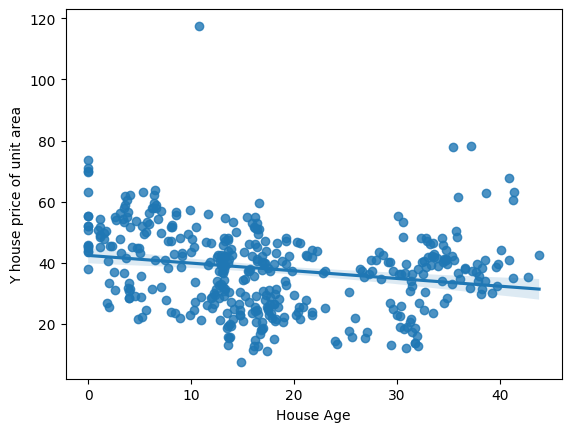

In [70]:
sns.regplot(x=data['X2 house age'], y=data['Y house price of unit area'])
plt.xlabel('House Age')

### Plot Distance to MRT station Vs Price

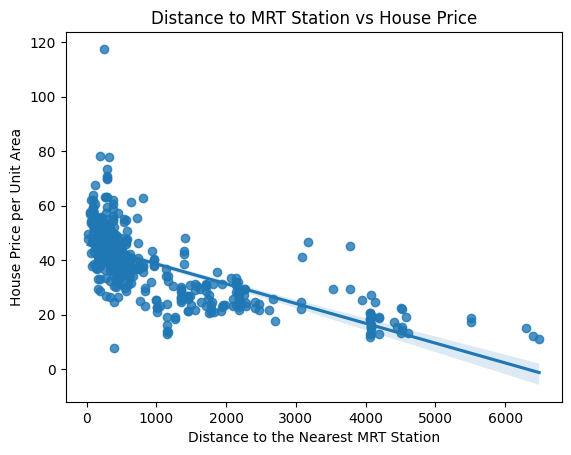

In [71]:
# Plot Distance to the MRT Station Vs Price
sns.regplot(x=data['X3 distance to the nearest MRT station'], y=data['Y house price of unit area'])
plt.xlabel('Distance to the Nearest MRT Station')
plt.ylabel('House Price per Unit Area')
plt.title('Distance to MRT Station vs House Price')
plt.show()

### Plot Number of Convienience Stores Vs Price

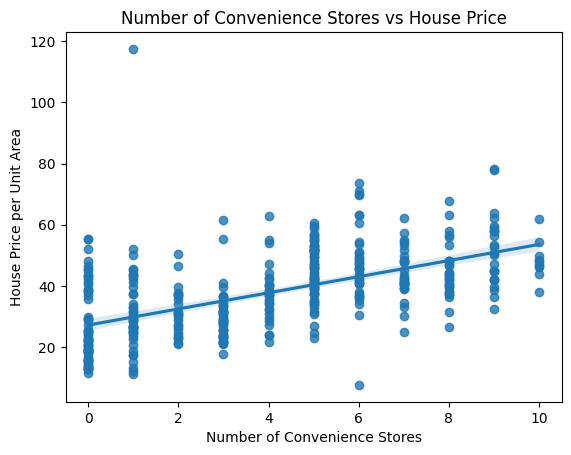

In [73]:
# Plot number of convenience stores Vs Price
# plt.figure(figsize=(10, 8))
sns.regplot(x=data['X4 number of convenience stores'], y=data['Y house price of unit area'], )
plt.xlabel('Number of Convenience Stores')
plt.ylabel('House Price per Unit Area')
plt.title('Number of Convenience Stores vs House Price')
plt.show()